# Render-parameter optimization: study results

Loads an Optuna study produced by `src/optimize_rendering.py` -- same-view macro-F1 as the objective, one trial per rendering-parameter combination -- and summarizes it: trial outcomes, the best parameters found, how the score evolved over trials, and which parameters actually mattered.

Point `STUDY_NAME`/`STORAGE` at whatever study you ran, e.g. after:
```
python src/optimize_rendering.py NFINITE100-CROSS/ NFINITE100-OPTIMIZE2/ --study-storage sqlite:///study.db --study-name test2
```

In [48]:
from pathlib import Path

import matplotlib.pyplot as plt
import optuna
import optuna.importance
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

STUDY_NAME = "test2"
STORAGE = f"sqlite:///{REPO_ROOT / 'study.db'}"

# Validated categorical palette, kept consistent across every chart below.
TRIAL_COLOR = "#2a78d6"
BEST_COLOR = "#eb6834"

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE)
trials_df = study.trials_dataframe()
print(f"{len(trials_df)} trials loaded from study {STUDY_NAME!r}")

95 trials loaded from study 'test2'


In [22]:
trials_df

,number,value,datetime_start,datetime_complete,duration,params_denoising,params_exposure,params_gi_bounces,params_material_mode,params_resolution,params_samples,params_shadow_softness,params_view_transform,state
0,0,0.122253,2026-09-01 19:16:06.601228,2026-09-01 19:30:00.018520,0 days 00:13:53.417292,True,-0.874887,7,full_pbr,512,27,6.999333,Filmic,COMPLETE
1,1,0.276278,2026-09-01 19:30:00.198101,2026-09-01 19:53:13.923685,0 days 00:23:13.725584,True,-1.212602,2,full_pbr,full_hd,11,3.392722,Filmic,COMPLETE
2,2,0.324405,2026-09-01 19:53:13.949546,2026-09-01 20:12:17.005892,0 days 00:19:03.056346,True,1.365247,3,full_pbr,hd,16,4.744071,AgX,COMPLETE
3,3,0.162522,2026-09-01 20:12:17.047681,2026-09-01 20:22:21.629756,0 days 00:10:04.582075,True,1.156370,12,full_pbr,512,22,11.484987,Standard,COMPLETE
4,4,0.224673,2026-09-01 20:22:21.663277,2026-09-01 20:31:10.755672,0 days 00:08:49.092395,False,1.700252,12,full_pbr,512,27,13.561493,Filmic,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,77,0.228588,2026-09-03 13:19:05.913299,2026-09-03 13:31:25.919280,0 days 00:12:20.005981,True,-0.701409,4,flat_color,hd,4,1.102465,AgX,COMPLETE
78,78,0.242906,2026-09-03 13:31:25.936523,2026-09-03 13:46:04.250966,0 days 00:14:38.314443,True,-0.938157,3,flat_color,hd,8,2.325350,AgX,COMPLETE
79,79,0.267507,2026-09-03 13:46:04.269272,2026-09-03 13:59:46.988772,0 days 00:13:42.719500,True,0.177313,2,flat_color,hd,6,5.782029,AgX,COMPLETE
80,80,0.281614,2026-09-03 13:59:47.028832,2026-09-03 14:23:03.167472,0 days 00:23:16.138640,True,-0.029666,5,flat_color,hd,7,1.899183,Filmic,COMPLETE


## Trial outcomes

`FAIL` trials have no score (see `optimize_rendering.py`'s `catch=(Exception,)` -- a bad render/VLM call fails just that trial rather than the whole study) and are dropped from every analysis below.

In [58]:
print(trials_df["state"].value_counts().to_string())

completed = trials_df[trials_df["state"] == "COMPLETE"].copy()
assert not completed.empty, "No completed trials to analyze -- every trial in this study failed."
print(f"\n{len(completed)} completed trials, macro_f1 range [{completed['value'].min():.3f}, {completed['value'].max():.3f}]")

state
COMPLETE    91
FAIL         3
RUNNING      1

91 completed trials, macro_f1 range [0.000, 0.414]


## Macro F1 summary: mean, max, min, std

Across every completed trial.

In [ ]:
completed["value"].agg(["mean", "max", "min", "std"]).round(3)

## Best trial

In [50]:
print(f"trial {study.best_trial.number}: same-view macro_f1 = {study.best_value:.3f}")
study.best_params

trial 87: same-view macro_f1 = 0.414


{'material_mode': 'clay',
 'view_transform': 'AgX',
 'shadow_softness': 2.0903005564870076,
 'gi_bounces': 5,
 'exposure': 0.22038195979776676,
 'samples': 6,
 'denoising': True,
 'resolution': 'hd'}

## Score over trials

Whether the study actually converged on something, or the best trial so far is just noise from a search that hasn't settled.

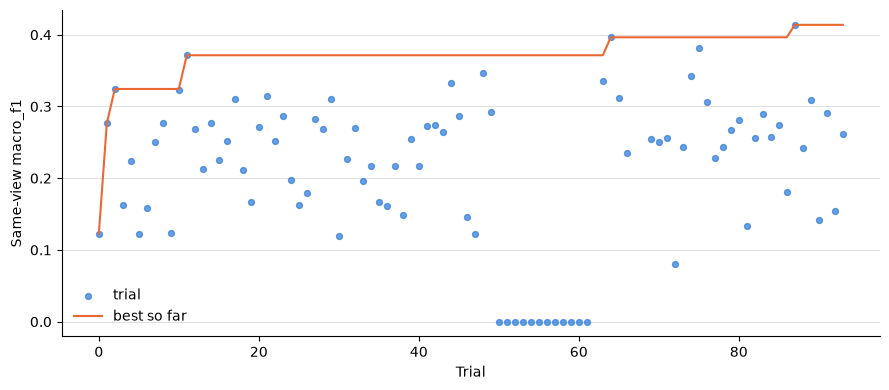

In [51]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(completed["number"], completed["value"], color=TRIAL_COLOR, s=18, alpha=0.7, label="trial")
ax.plot(completed["number"], completed["value"].cummax(), color=BEST_COLOR, linewidth=1.5, label="best so far")
ax.set_xlabel("Trial")
ax.set_ylabel("Same-view macro_f1")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Which parameters mattered

`optuna.importance` fits a surrogate model over completed trials and attributes score variance to each parameter -- this ranks *how much* each one matters, not which direction it pushes the score (see the per-parameter breakdown below for that).

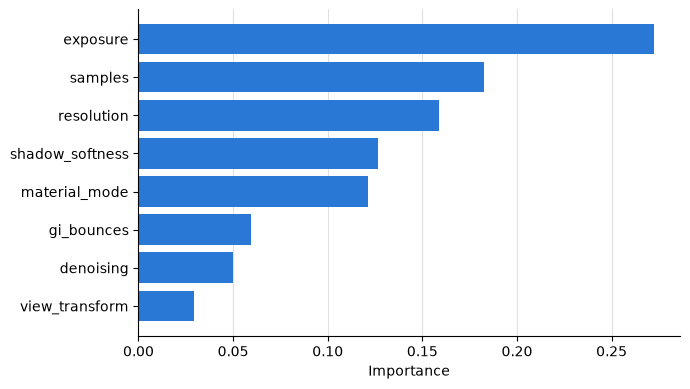

In [52]:
importances = pd.Series(optuna.importance.get_param_importances(study), name="importance").sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importances.index, importances.values, color=TRIAL_COLOR)
ax.set_xlabel("Importance")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [53]:
importances

view_transform     0.029326
denoising          0.050076
gi_bounces         0.059320
material_mode      0.121122
shadow_softness    0.126674
resolution         0.158531
samples            0.182449
exposure           0.272502
Name: importance, dtype: float64

## Score by parameter value

Categorical/low-cardinality parameters as boxplots, continuous ones as scatter -- the actual direction of each effect.

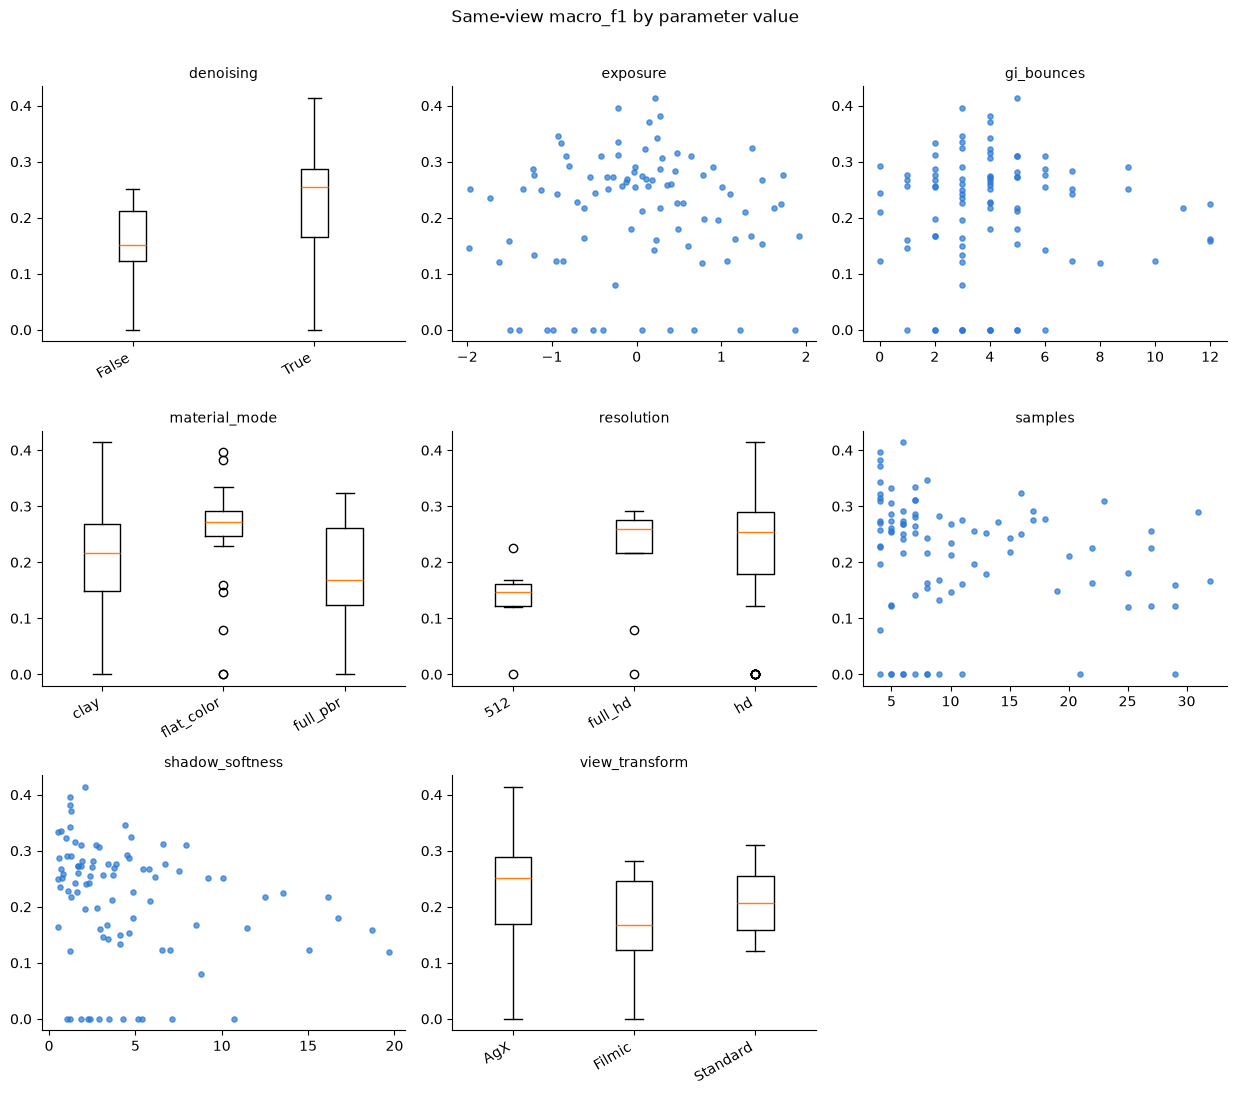

In [57]:
param_cols = [c for c in completed.columns if c.startswith("params_")]
n_cols = 3
n_rows = -(-len(param_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, param_cols):
    name = col.removeprefix("params_")
    values = completed[col]

    if values.dtype == object or values.nunique() <= 6:
        order = sorted(values.dropna().unique(), key=str)
        data = [completed.loc[values == v, "value"] for v in order]
        ax.boxplot(data)
        # Not boxplot(..., labels=...)/tick_labels=: that kwarg was renamed between matplotlib
        # versions (labels -> tick_labels), so setting ticks directly works on either.
        ax.set_xticks(range(1, len(order) + 1))
        ax.set_xticklabels([str(v) for v in order], rotation=30, ha="right")
    else:
        ax.scatter(values, completed["value"], color=TRIAL_COLOR, s=14, alpha=0.7)

    ax.set_title(name, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(param_cols):]:
    ax.axis("off")

fig.suptitle("Same-view macro_f1 by parameter value", y=1.01)
fig.tight_layout()
plt.show()

## Top trials

If the study was run with `--keep-renders`, each of these has a `trial_<number>/` directory under the study's `work_dir` with the actual rendered images and raw VLM responses for closer inspection.

In [55]:
display_cols = ["number", "value"] + param_cols
completed.sort_values("value", ascending=False)[display_cols].head(10).reset_index(drop=True)

,number,value,params_denoising,params_exposure,params_gi_bounces,params_material_mode,params_resolution,params_samples,params_shadow_softness,params_view_transform
0,87,0.413828,True,0.220382,5,clay,hd,6,2.090301,AgX
1,64,0.396461,True,-0.218867,3,flat_color,hd,4,1.197011,AgX
2,75,0.382143,True,0.278539,4,flat_color,hd,4,1.185327,AgX
3,11,0.371429,True,0.145261,4,clay,hd,4,1.253448,AgX
4,48,0.346161,True,-0.932179,3,clay,hd,8,4.423147,AgX
5,74,0.342857,True,0.238151,4,clay,hd,4,1.221437,AgX
6,63,0.334914,True,-0.222048,3,flat_color,hd,7,0.683099,AgX
7,44,0.332846,True,-0.898189,2,flat_color,hd,5,0.530390,AgX
8,2,0.324405,True,1.365247,3,full_pbr,hd,16,4.744071,AgX
9,10,0.322512,True,0.098709,4,clay,hd,4,0.992330,AgX
